<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week3_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [21]:
#Forward Selection
def forward_selection(X, y, significance_level=0.05):
  initial_features = []
  remaining_features = list(X.columns)

  while remaining_features:
    pvals =  pd.Series(index=remaining_features, dtype=float)

    for feature in remaining_features:
      features = initial_features+[feature]
      model = sm.OLS(y, sm.add_constant(X[features])).fit()
      pvals[feature] = model.pvalues[feature]
    min_p = pvals.min()

    if min_p < significance_level:
      best_feature = pvals.idxmin()
      initial_features.append(best_feature)
      remaining_features.remove(best_feature)
    else:
      break
  return initial_features
selected_features = forward_selection(X_train, y_train)
print(selected_features)

#Fit linear model
model_forward = LinearRegression()
model_forward.fit(X_train[selected_features], y_train)
y_pred_forward = model_forward.predict(X_test[selected_features])


['concave_points3', 'radius3', 'texture3', 'area3', 'smoothness2', 'symmetry3', 'radius2', 'compactness2', 'concavity3']


In [22]:
#backward selection
def backward_selection(X, y, significance_level=0.05):
  features = list(X.columns)
  while len(features)>0:
    model = sm.OLS(y, sm.add_constant(X[features])).fit()
    pvals = model.pvalues.iloc[1:]
    max_p = pvals.max()
    if max_p > significance_level:
      worst_feature = pvals.idxmax()
      features.remove(worst_feature)
    else:
      break
  return features
selected_features_back = backward_selection(X_train, y_train)
print(selected_features_back)


#Fit linear model
model_backward = LinearRegression()
model_backward.fit(X_train[selected_features_back], y_train)
y_pred_backward = model_backward.predict(X_test[selected_features_back])


['compactness1', 'concave_points1', 'fractal_dimension1', 'radius2', 'smoothness2', 'concavity2', 'concave_points2', 'radius3', 'texture3', 'area3', 'concavity3', 'symmetry3']


In [11]:
#PCA Regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#Fit linear model
model_pcr = LinearRegression()
model_pcr.fit(X_train_pca, y_train)
y_pred_pcr = model_pcr.predict(X_test_pca)


In [30]:
#Partial Least Squares Regression(PLSR)
from sklearn.cross_decomposition import PLSRegression
model_pls = PLSRegression(n_components=10)
model_pls.fit(X_train_scaled, y_train)
y_pred_pls = model_pls.predict(X_test_scaled)


In [31]:
#Models performances
from sklearn.metrics import mean_squared_error, r2_score

models = {"Forward": (model_forward, X_test[selected_features]),
          "Backward": (model_backward, X_test[selected_features_back]),
          "PCR": (model_pcr, X_test_pca)}

for name, (model, X_data) in models.items():
  pred =  model.predict(X_data)
  print(name)
  print("R2:", r2_score(y_test, pred))
  print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
  print("\n")

print("PLSR R2: ", r2_score(y_test, y_pred_pls))
print("PLSR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pls)))

Forward
R2: 0.7605117929808802
RMSE: 0.23724546090686338


Backward
R2: 0.7606541867773791
RMSE: 0.2371749202624554


PCR
R2: 0.7318199746999932
RMSE: 0.2510551065330094


PLSR R2:  0.7469853957134209
PLSR RMSE: 0.2438533019904538


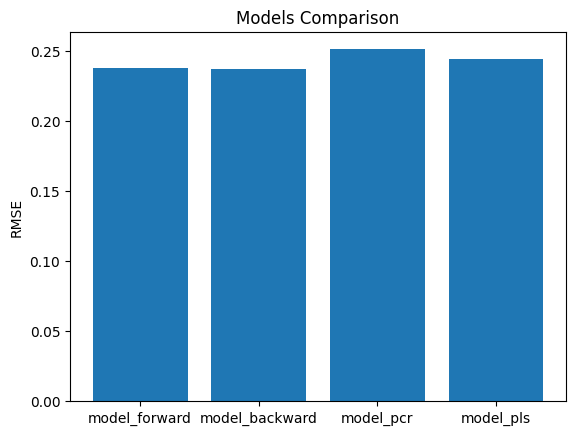

In [32]:
#Model comparison
import matplotlib.pyplot as plt
models = ['model_forward','model_backward','model_pcr','model_pls']
rmse_forward= np.sqrt(mean_squared_error(y_test, y_pred_forward))
rmse_backward= np.sqrt(mean_squared_error(y_test, y_pred_backward))
rmse_pcr= np.sqrt(mean_squared_error(y_test, y_pred_pcr))
rmse_plsr = np.sqrt(mean_squared_error(y_test, y_pred_pls))

rmse = [rmse_forward, rmse_backward, rmse_pcr, rmse_plsr]
plt.bar(models, rmse)
plt.ylabel("RMSE")
plt.title("Models Comparison")
plt.show()

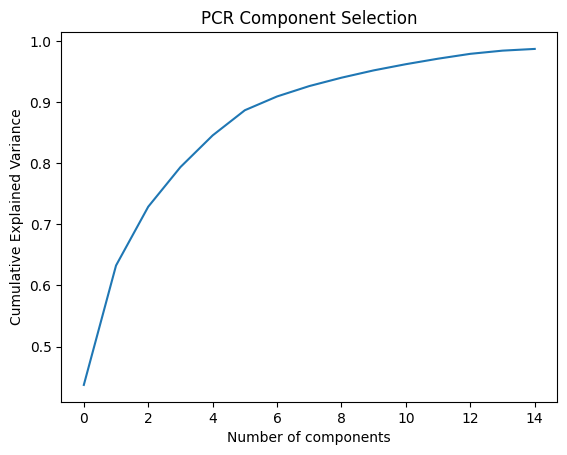

In [40]:
#PCR Explained Variance Plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCR Component Selection")
plt.show()

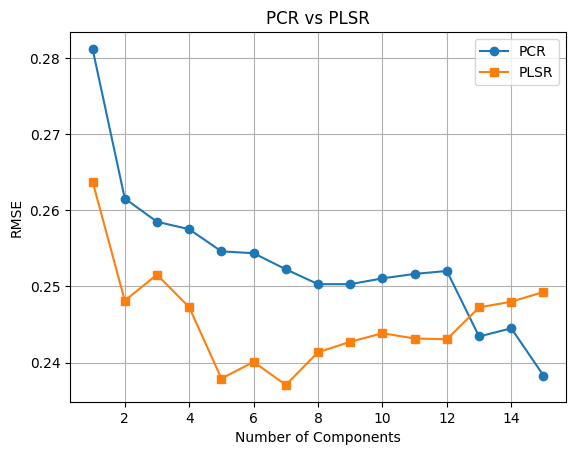

In [43]:
#PCR vs PLSR RMSE vs Components Plot
#PCR
rmse_pcr = []
for n in range(1,16):
  pca = PCA(n_components=n)
  X_train_pca = pca.fit_transform(X_train_scaled)
  X_test_pca = pca.transform(X_test_scaled)
  model = LinearRegression()
  model.fit(X_train_pca, y_train)
  y_pred = model.predict(X_test_pca)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  rmse_pcr.append(rmse)

#PLSR
rmse_plsr = []
for n in range(1,16):
  pls = PLSRegression(n_components=n)
  pls.fit(X_train_scaled, y_train)
  y_pred = pls.predict(X_test_scaled).ravel()
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  rmse_plsr.append(rmse)


#plot the data
components = range(1,16)
plt.plot(components, rmse_pcr, marker = 'o')
plt.plot(components, rmse_plsr, marker='s')
plt.xlabel("Number of Components")
plt.ylabel("RMSE")
plt.title("PCR vs PLSR")
plt.legend(["PCR", "PLSR"])
plt.grid(True)
plt.show()
